# Transit GTFS Cleaning & EDA – San Diego Youth Opportunity Project

**Author: Lauren Vo**

Built a clean, unified transit **stops** dataset from the MTS GTFS exports to use as an access layer in the “youth opportunity deserts” map.

**This notebook focuses on the transit (access) layer:**

1. Load raw GTFS-derived files from `data/raw/services`:
   - `Transit_Routes_GTFS.csv`
   - `Transit_Stops_GTFS_20251028.csv`
2. Clean and standardize **routes** and **stops** tables.
3. Build an “ideal-ish” transit stops dataset:

   - One row per transit stop.
   - Columns: `stop_id`, `stop_name`, `stop_lat`, `stop_lon`, `stop_agency`,
     `stop_code`, `location_type`, `parent_station`, `wheelchair_boarding`,
     `intersection_code`, `stop_place`.

4. Run basic EDA:
   - Counts of routes by agency and type.
   - Counts of stops by agency and wheelchair accessibility.
   - Lat/lon sanity checks and missingness.

Outputs will be written to `data/processed/services` for now, so they can be joined with the services layer later.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

candidates = [Path("."), Path(".."), Path("../..")]

PROJECT_ROOT = None
for cand in candidates:
    if (cand / "data" / "raw" / "services").exists():
        PROJECT_ROOT = cand.resolve()
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not find data/raw/services from this notebook location.")

print("Using PROJECT_ROOT:", PROJECT_ROOT)

DATA_DIR = PROJECT_ROOT / "data"
RAW_SERVICES_DIR = DATA_DIR / "raw" / "services"
PROCESSED_SERVICES_DIR = DATA_DIR / "processed" / "services"

PROCESSED_SERVICES_DIR.mkdir(parents=True, exist_ok=True)

RAW_SERVICES_DIR, PROCESSED_SERVICES_DIR


Using PROJECT_ROOT: /Users/laurenvo/Documents/github/Mapping-Youth-Opportunity-Deserts


(PosixPath('/Users/laurenvo/Documents/github/Mapping-Youth-Opportunity-Deserts/data/raw/services'),
 PosixPath('/Users/laurenvo/Documents/github/Mapping-Youth-Opportunity-Deserts/data/processed/services'))

In [2]:
def summarize_dataset(df: pd.DataFrame, name: str):
    """Quick text summary for EDA."""
    print(f"\n=== {name} ===")
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    print(df.head(3))
    print("\nMissing values (%):")
    print((df.isna().mean() * 100).round(1))

def clip_lat_lon(df, lat_col="lat", lon_col="lon"):
    """Clip lat/lon outside a rough San Diego County bounding box."""
    lat_ok = df[lat_col].between(32.0, 33.5)
    lon_ok = df[lon_col].between(-117.7, -116.0)
    bad = ~(lat_ok & lon_ok)
    print(f"Setting lat/lon to NaN for {bad.sum()} rows outside SD bounding box.")
    df.loc[bad, [lat_col, lon_col]] = np.nan
    return df


In [3]:
routes_path = RAW_SERVICES_DIR / "Transit_Routes_GTFS.csv"
stops_path = RAW_SERVICES_DIR / "Transit_Stops_GTFS_20251028.csv"

routes_raw = pd.read_csv(routes_path, low_memory=False)
stops_raw = pd.read_csv(stops_path, low_memory=False)

summarize_dataset(routes_raw, "GTFS routes (raw)")
summarize_dataset(stops_raw, "GTFS stops (raw)")



=== GTFS routes (raw) ===
Shape: (478, 16)
Columns: ['OID_', 'shape_id', 'route_id', 'route_short_name', 'route_long_name', 'route_type', 'agency_id', 'route_desc', 'route_url', 'route_color', 'route_text_color', 'route_type_text', 'RouteShapeName', 'route_color_RGB', 'route_text_color_RGB', 'Shape_Length']
   OID_ shape_id route_id route_short_name          route_long_name  route_type agency_id  route_desc                     route_url  \
0     1  3010111      301              101  Oceanside - UTC/VA/UCSD           3      NCTD         NaN  http://www.gonctd.com/breeze   
1     2  3010125      301              101  Oceanside - UTC/VA/UCSD           3      NCTD         NaN  http://www.gonctd.com/breeze   
2     3  3010130      301              101  Oceanside - UTC/VA/UCSD           3      NCTD         NaN  http://www.gonctd.com/breeze   

  route_color route_text_color route_type_text RouteShapeName route_color_RGB route_text_color_RGB   Shape_Length  
0      008C9B           FFFFFF   

In [4]:
routes = routes_raw.copy()

# Rename some columns for readability
routes = routes.rename(
    columns={
        "route_short_name": "route_short",
        "route_long_name": "route_long",
        "route_type_text": "route_type_text",
    }
)

# Ensure numeric types where appropriate
routes["route_type"] = pd.to_numeric(routes["route_type"], errors="coerce").astype("Int64")

# Keep core route-level information
route_cols = [
    "route_id",
    "route_short",
    "route_long",
    "route_type",
    "route_type_text",
    "agency_id",
    "route_desc",
    "route_url",
    "route_color",
    "route_text_color",
]

route_cols = [c for c in route_cols if c in routes.columns]
routes_clean = routes[route_cols].copy()

# Deduplicate by route_id + route_short + route_long
routes_clean = (
    routes_clean
    .sort_values(["route_id", "route_short"])
    .drop_duplicates(subset=["route_id", "route_short", "route_long"], keep="first")
    .reset_index(drop=True)
)

summarize_dataset(routes_clean, "GTFS routes (clean)")

routes_clean.to_csv(PROCESSED_SERVICES_DIR / "transit_routes_clean.csv", index=False)



=== GTFS routes (clean) ===
Shape: (146, 10)
Columns: ['route_id', 'route_short', 'route_long', 'route_type', 'route_type_text', 'agency_id', 'route_desc', 'route_url', 'route_color', 'route_text_color']
  route_id route_short                     route_long  route_type route_type_text agency_id  route_desc  \
0        1           1       Fashion Valley - La Mesa           3             Bus       MTS         NaN   
1       10          10  Old Town - University/College           3             Bus       MTS         NaN   
2      105         105     Old Town - University City           3             Bus       MTS         NaN   

                                           route_url route_color route_text_color  
0  https://www.sdmts.com/schedules-real-time?frag...      000099           FFFFFF  
1  https://www.sdmts.com/schedules-real-time?frag...      000099           FFFFFF  
2  https://www.sdmts.com/schedules-real-time?frag...      000099           FFFFFF  

Missing values (%):
route_id 

In [ ]:
stops = stops_raw.copy()

# Drop geometry columns not needed in analysis
drop_cols = [c for c in ["the_geom", "OBJECTID"] if c in stops.columns]
stops = stops.drop(columns=drop_cols)

# Ensure numeric latitude/longitude
stops["stop_lat"] = pd.to_numeric(stops["stop_lat"], errors="coerce")
stops["stop_lon"] = pd.to_numeric(stops["stop_lon"], errors="coerce")

# Clip to SD bounding box to remove obvious coordinate errors
stops = clip_lat_lon(stops, lat_col="stop_lat", lon_col="stop_lon")

# Standardize wheelchair_boarding & location_type as nullable integers
for col in ["wheelchair_boarding", "location_type"]:
    if col in stops.columns:
        stops[col] = pd.to_numeric(stops[col], errors="coerce").astype("Int64")

# Make sure these columns exist, even if empty (for schema consistency)
for col in [
    "stop_agency",
    "stop_code",
    "parent_station",
    "intersection_code",
    "stop_place",
]:
    if col not in stops.columns:
        stops[col] = np.nan

# Build a tidy, stop-level table
stops_ideal = stops[
    [
        "stop_id",
        "stop_name",
        "stop_lat",
        "stop_lon",
        "stop_agency",
        "stop_code",
        "location_type",
        "parent_station",
        "wheelchair_boarding",
        "intersection_code",
        "stop_place",
    ]
].copy()

# Deduplicate: one row per stop_id
# If there are duplicates, keep the one that has lat/lon and a non-null stop_name.
stops_ideal["has_coords"] = stops_ideal["stop_lat"].notna() & stops_ideal["stop_lon"].notna()
stops_ideal["has_name"] = stops_ideal["stop_name"].notna()

stops_ideal = (
    stops_ideal
    .sort_values(
        ["stop_id", "has_coords", "has_name"],
        ascending=[True, False, False],
    )
    .drop_duplicates(subset=["stop_id"], keep="first")
    .reset_index(drop=True)
)

stops_ideal = stops_ideal.drop(columns=["has_coords", "has_name"])

summarize_dataset(stops_ideal, "GTFS stops (ideal schema, 1 row per stop)")

# Save outputs
stops_ideal.to_csv(PROCESSED_SERVICES_DIR / "transit_stops_master.csv", index=False)

# A slim version designed for mapping
stops_for_mapping = stops_ideal[
    ["stop_id", "stop_name", "stop_lat", "stop_lon", "stop_agency", "wheelchair_boarding"]
].copy()

stops_for_mapping.to_csv(PROCESSED_SERVICES_DIR / "transit_stops_for_mapping.csv", index=False)


Setting lat/lon to NaN for 0 rows outside SD bounding box.

=== GTFS stops (ideal schema, 1 row per stop) ===
Shape: (6173, 11)
Columns: ['stop_id', 'stop_name', 'stop_lat', 'stop_lon', 'stop_agency', 'stop_code', 'location_type', 'parent_station', 'wheelchair_boarding', 'intersection_code', 'stop_place']
  stop_id                   stop_name   stop_lat    stop_lon stop_agency  stop_code  location_type parent_station  wheelchair_boarding  \
0   10001  Cabrillo National Monument  32.674458 -117.240426         MTS    10001.0              0            NaN                    1   
1   10003        Pearl St & Draper Av  32.839578 -117.276187         MTS    10003.0              0            NaN                    1   
2   10004           Pearl St & Fay Av  32.840128 -117.273810         MTS    10004.0              0            NaN                    1   

  intersection_code stop_place  
0     M-Special_Loc     cabmon  
1             N-E/B        NaN  
2             N-E/B        NaN  

Missing

In [6]:
print("Total routes:", len(routes_clean))

print("\nRoutes by agency_id:")
print(routes_clean["agency_id"].value_counts(dropna=False))

print("\nRoutes by route_type_text:")
if "route_type_text" in routes_clean.columns:
    print(routes_clean["route_type_text"].value_counts())
else:
    print("route_type_text column not present.")

print("\nRoutes by agency_id and type (top 15 combos):")
print(
    routes_clean
    .groupby(["agency_id", "route_type_text"])
    .size()
    .sort_values(ascending=False)
    .head(15)
)


Total routes: 146

Routes by agency_id:
agency_id
MTS     104
NCTD     42
Name: count, dtype: int64

Routes by route_type_text:
route_type_text
Bus                            140
Tram, Streetcar, Light rail      5
Rail                             1
Name: count, dtype: int64

Routes by agency_id and type (top 15 combos):
agency_id  route_type_text            
MTS        Bus                            100
NCTD       Bus                             40
MTS        Tram, Streetcar, Light rail      4
NCTD       Rail                             1
           Tram, Streetcar, Light rail      1
dtype: int64


In [7]:
print("Total stops:", len(stops_ideal))

print("\nStops by agency:")
print(stops_ideal["stop_agency"].value_counts(dropna=False))

print("\nWheelchair boarding codes (0 = no info, 1 = some access, 2 = no access, per GTFS):")
print(stops_ideal["wheelchair_boarding"].value_counts(dropna=False))

print("\nLocation types (0=stop/platform, 1=station, etc.):")
print(stops_ideal["location_type"].value_counts(dropna=False))

print("\nMissing coordinates:")
print((stops_ideal[["stop_lat", "stop_lon"]].isna().mean() * 100).round(2))

print("\nLat range:", stops_ideal["stop_lat"].min(), "→", stops_ideal["stop_lat"].max())
print("Lon range:", stops_ideal["stop_lon"].min(), "→", stops_ideal["stop_lon"].max())


Total stops: 6173

Stops by agency:
stop_agency
MTS     4365
NCTD    1808
Name: count, dtype: int64

Wheelchair boarding codes (0 = no info, 1 = some access, 2 = no access, per GTFS):
wheelchair_boarding
1       3160
<NA>    1808
0        738
2        467
Name: count, dtype: Int64

Location types (0=stop/platform, 1=station, etc.):
location_type
0    6058
1     115
Name: count, dtype: Int64

Missing coordinates:
stop_lat    0.0
stop_lon    0.0
dtype: float64

Lat range: 32.54281914 → 33.394164
Lon range: -117.514206 → -116.18445788


In [8]:
# A quick view of a few random stops to visually QA names/coords
stops_ideal.sample(10, random_state=42)


,stop_id,stop_name,stop_lat,stop_lon,stop_agency,stop_code,location_type,parent_station,wheelchair_boarding,intersection_code,stop_place
5700,98130,Hwy 94 & Proctor Valley Rd,32.716942,-116.876464,MTS,98130.0,0,NaN,2,N-E/B,jamul
3007,21985,Stuart Mesa & Edson Range,33.258650,-117.414291,NCTD,21985.0,0,NaN,<NA>,N-W/B,NaN
1902,13170,La Mesa Bl & University Av,32.765228,-117.026556,MTS,13170.0,0,NaN,1,F-N/B,NaN
346,10560,University Av & 33rd St,32.748736,-117.121811,MTS,10560.0,0,NaN,1,M-Street-E/B,NaN
1730,12861,Logan Av & 43rd St,32.696655,-117.102111,MTS,12861.0,0,NaN,1,F-E/B,NaN
5835,99207,Westonhill Dr & Gold Coast Dr,32.906147,-117.135596,MTS,99207.0,0,NaN,1,N-S/B,NaN
2063,20018,Division St & Grant St,33.196127,-117.370258,NCTD,20018.0,0,NaN,<NA>,N-E/B,NaN
3018,22009,San Rodolfo Dr & Plaza West,32.994151,-117.259783,NCTD,22009.0,0,NaN,<NA>,F-W/B,NaN
3352,22839,Santa Fe Dr & Mackinnon Av,33.036198,-117.275802,NCTD,22839.0,0,NaN,<NA>,F-E/B,NaN
1172,11921,Genesee Av & Esplanade Ct,32.869959,-117.214192,MTS,11921.0,0,NaN,1,F-S/B,utc_2


In [ ]:
routes_clean.to_csv(PROCESSED_SERVICES_DIR / "transit_routes_clean.csv", index=False)
stops_ideal.to_csv(PROCESSED_SERVICES_DIR / "transit_stops_master.csv", index=False)
stops_for_mapping.to_csv(PROCESSED_SERVICES_DIR / "transit_stops_for_mapping.csv", index=False)


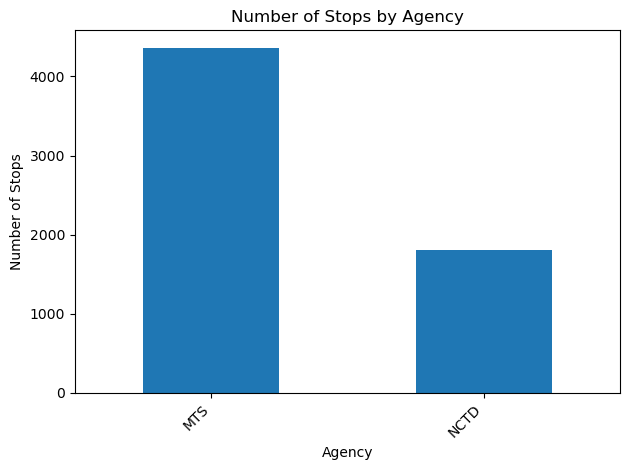

In [10]:
import matplotlib.pyplot as plt

agency_counts = (
    stops_ideal["stop_agency"]
    .fillna("Unknown")
    .value_counts()
)

plt.figure()
agency_counts.plot(kind="bar")
plt.title("Number of Stops by Agency")
plt.xlabel("Agency")
plt.ylabel("Number of Stops")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


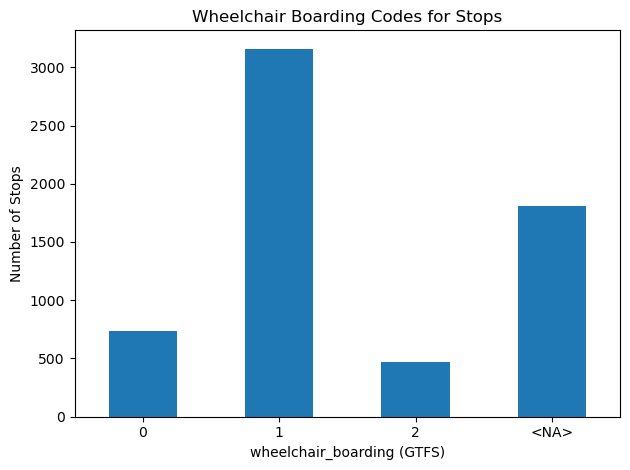

In [11]:
wheel_counts = (
    stops_ideal["wheelchair_boarding"]
    .astype("Int64")
    .value_counts(dropna=False)
    .sort_index()
)

plt.figure()
wheel_counts.plot(kind="bar")
plt.title("Wheelchair Boarding Codes for Stops")
plt.xlabel("wheelchair_boarding (GTFS)")
plt.ylabel("Number of Stops")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


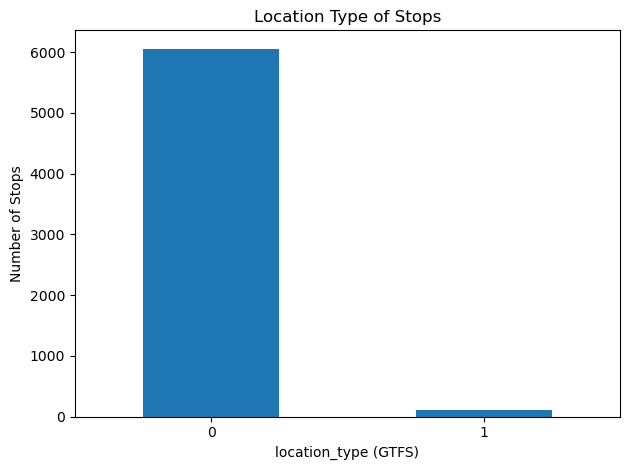

In [12]:
loc_counts = (
    stops_ideal["location_type"]
    .astype("Int64")
    .value_counts(dropna=False)
    .sort_index()
)

plt.figure()
loc_counts.plot(kind="bar")
plt.title("Location Type of Stops")
plt.xlabel("location_type (GTFS)")
plt.ylabel("Number of Stops")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


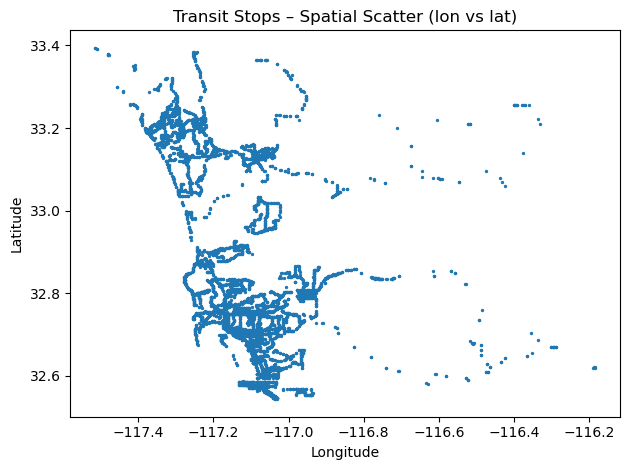

In [13]:
plt.figure()
plt.scatter(
    stops_ideal["stop_lon"],
    stops_ideal["stop_lat"],
    s=2,
)
plt.title("Transit Stops – Spatial Scatter (lon vs lat)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()


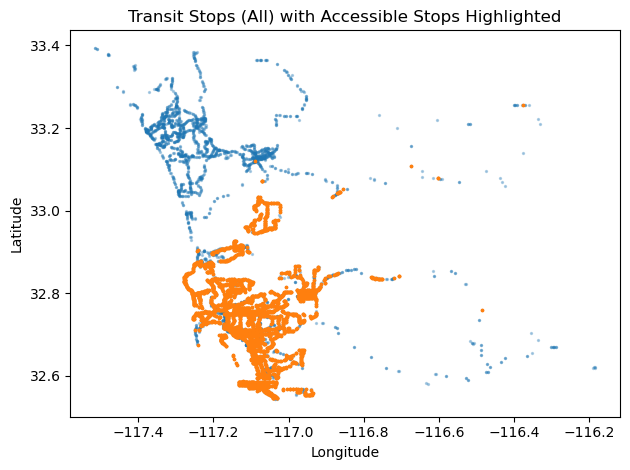

In [14]:
accessible = stops_ideal[stops_ideal["wheelchair_boarding"] == 1]

plt.figure()
plt.scatter(
    stops_ideal["stop_lon"],
    stops_ideal["stop_lat"],
    s=2,
    alpha=0.3,
)
plt.scatter(
    accessible["stop_lon"],
    accessible["stop_lat"],
    s=3,
)
plt.title("Transit Stops (All) with Accessible Stops Highlighted")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()


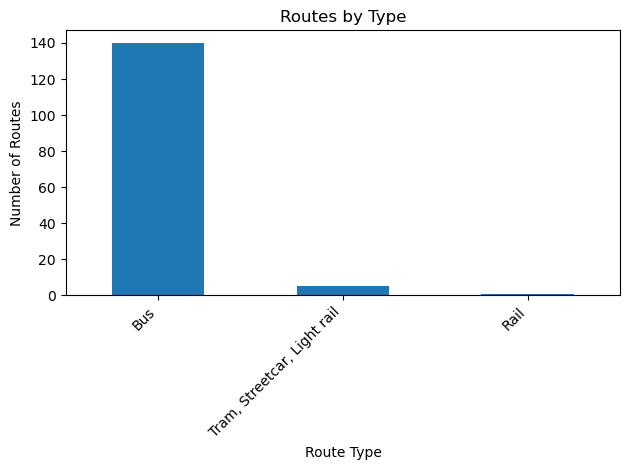

In [15]:
route_type_counts = routes_clean["route_type_text"].value_counts()

plt.figure()
route_type_counts.plot(kind="bar")
plt.title("Routes by Type")
plt.xlabel("Route Type")
plt.ylabel("Number of Routes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
